# Cours Pandas : Analyse et Combinaison de Données
Ce cours approfondit les capacités de Pandas pour l'**analyse exploratoire de données** (EDA) et la **combinaison de plusieurs sources de données**. Nous verrons comment décrire un dataset, effectuer des calculs statistiques, grouper et agréger des données, ainsi que fusionner des DataFrames de différentes manières.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

---

## Partie : Analyse de Données

---

### 1. Les méthodes de descriptions générales du dataset

#### Théorie

Pour avoir un premier aperçu d'un DataFrame, Pandas offre plusieurs méthodes : `df.head()`, `df.tail()`, `df.info()`, `df.shape`, `df.columns`, `df.dtypes` et `df.describe()`.
`describe()` est particulièrement utile pour obtenir des statistiques descriptives des colonnes numériques.

#### Exemple

In [3]:
data = {'A': [1, 2, 3, 4, 5], 'B': [6.0, 7.1, 8.2, 9.3, 10.4], 'C': ['x', 'y', 'z', 'x', 'y']}
df = pd.DataFrame(data)
print("df.head():\n", df.head())
print("\ndf.info():")
df.info()
print("\ndf.describe():\n", df.describe())
print("\ndf.shape:", df.shape)
print("\ndf.columns:", df.columns)
print("\ndf.dtypes:\n", df.dtypes)

df.head():
    A     B  C
0  1   6.0  x
1  2   7.1  y
2  3   8.2  z
3  4   9.3  x
4  5  10.4  y

df.info():
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       5 non-null      int64  
 1   B       5 non-null      float64
 2   C       5 non-null      str    
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes

df.describe():
               A          B
count  5.000000   5.000000
mean   3.000000   8.200000
std    1.581139   1.739253
min    1.000000   6.000000
25%    2.000000   7.100000
50%    3.000000   8.200000
75%    4.000000   9.300000
max    5.000000  10.400000

df.shape: (5, 3)

df.columns: Index(['A', 'B', 'C'], dtype='str')

df.dtypes:
 A      int64
B    float64
C        str
dtype: object


#### Exercice

Chargez le dataset 'tips' de Seaborn et utilisez les méthodes vues pour en faire une description générale.

#### Correction

In [4]:
tips = sns.load_dataset('tips')
print("tips.head():\n", tips.head())
print("\ntips.info():")
tips.info()
print("\ntips.describe():\n", tips.describe())

tips.head():
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

tips.info():
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

tips.describe():
        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.

---

### 2. Méthodes statistiques basiques

#### Théorie

Pandas permet de calculer facilement des statistiques univariées sur des séries ou des colonnes de DataFrame : `mean()`, `median()`, `mode()`, `std()` (écart-type), `var()` (variance), `min()`, `max()`, `sum()`.

#### Exemple

In [5]:
df = pd.DataFrame({'Valeur': [10, 20, 30, 40, 50, 10]})
print(f"Moyenne: {df['Valeur'].mean()}")
print(f"Médiane: {df['Valeur'].median()}")
print(f"Mode: {df['Valeur'].mode().tolist()}")
print(f"Écart-type: {df['Valeur'].std()}")
print(f"Minimum: {df['Valeur'].min()}")
print(f"Maximum: {df['Valeur'].max()}")

Moyenne: 26.666666666666668
Médiane: 25.0
Mode: [10]
Écart-type: 16.329931618554518
Minimum: 10
Maximum: 50


#### Exercice

Pour le DataFrame `df_ventes` ci-dessous, calculez le revenu total, le revenu moyen par transaction, et l'écart-type des quantités vendues.
```python
df_ventes = pd.DataFrame({
    'transaction_id': [1, 2, 3, 4, 5],
    'produit': ['A', 'B', 'A', 'C', 'B'],
    'quantite': [2, 1, 3, 5, 2],
    'prix_unitaire': [10.0, 25.0, 10.0, 5.0, 25.0]
})
df_ventes['revenu'] = df_ventes['quantite'] * df_ventes['prix_unitaire']
```

#### Correction

In [6]:
df_ventes = pd.DataFrame({
    'transaction_id': [1, 2, 3, 4, 5],
    'produit': ['A', 'B', 'A', 'C', 'B'],
    'quantite': [2, 1, 3, 5, 2],
    'prix_unitaire': [10.0, 25.0, 10.0, 5.0, 25.0]
})
df_ventes['revenu'] = df_ventes['quantite'] * df_ventes['prix_unitaire']
total_revenu = df_ventes['revenu'].sum()
moyenne_revenu = df_ventes['revenu'].mean()
std_quantite = df_ventes['quantite'].std()
print(f"Revenu total: {total_revenu:.2f} $")
print(f"Revenu moyen par transaction: {moyenne_revenu:.2f} $")
print(f"Écart-type des quantités vendues: {std_quantite:.2f}")

Revenu total: 150.00 $
Revenu moyen par transaction: 30.00 $
Écart-type des quantités vendues: 1.52


---

### 3. Comptabilisation des valeurs

#### Théorie

La méthode `value_counts()` est fondamentale pour comprendre la distribution de catégories dans une colonne. Elle retourne une série contenant le nombre d'occurrences uniques dans l'ordre décroissant.

#### Exemple

In [7]:
df = pd.DataFrame({'Couleur': ['Rouge', 'Bleu', 'Vert', 'Rouge', 'Bleu', 'Rouge']})
print(df['Couleur'].value_counts())

# Avec pourcentage
print("\nAvec pourcentage :\n", df['Couleur'].value_counts(normalize=True))

Couleur
Rouge    3
Bleu     2
Vert     1
Name: count, dtype: int64

Avec pourcentage :
 Couleur
Rouge    0.500000
Bleu     0.333333
Vert     0.166667
Name: proportion, dtype: float64


#### Exercice

Pour le dataset 'titanic' de Seaborn, comptez le nombre de passagers par classe ('class') et par genre ('sex').

In [27]:
titanic = sns.load_dataset('titanic')
print("\nNombree de passager par classe:\n", titanic['class'].value_counts())
print("\nNombre de passsager par genre :\n", titanic['sex'].value_counts())
print("\nPourcentage de nombre de passager par classe:\n", titanic['class'].value_counts(normalize=True))
print("Pourcentage de nombre de passager par genre:\n", titanic['sex'].value_counts(normalize=True))


Nombree de passager par classe:
 class
Third     491
First     216
Second    184
Name: count, dtype: int64

Nombre de passsager par genre :
 sex
male      577
female    314
Name: count, dtype: int64

Pourcentage de nombre de passager par classe:
 class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64
Pourcentage de nombre de passager par genre:
 sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


#### Correction

In [26]:
titanic = sns.load_dataset('titanic')
print("Nombre de passagers par classe :\n", titanic['class'].value_counts())
print("\nNombre de passagers par genre :\n", titanic['sex'].value_counts())

Nombre de passagers par classe :
 class
Third     491
First     216
Second    184
Name: count, dtype: int64

Nombre de passagers par genre :
 sex
male      577
female    314
Name: count, dtype: int64


---

### 4. Analyse d'une distribution avec Pandas

#### Théorie

Outre `describe()` et `value_counts()`, l'analyse d'une distribution implique souvent la visualisation (histogrammes, boxplots) et le calcul de quantiles (`quantile()`).

#### Exemple

Quantiles de l'âge :
 0.25    25.75
0.50    31.50
0.75    38.75
Name: Age, dtype: float64


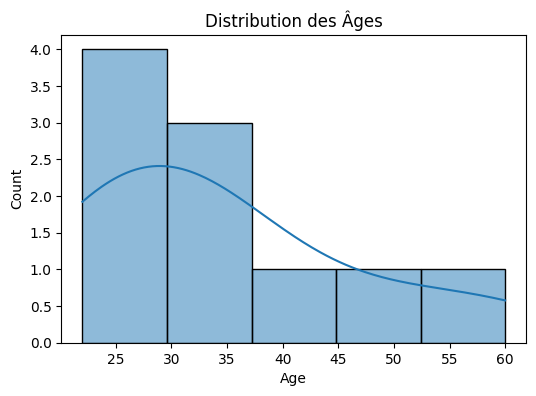

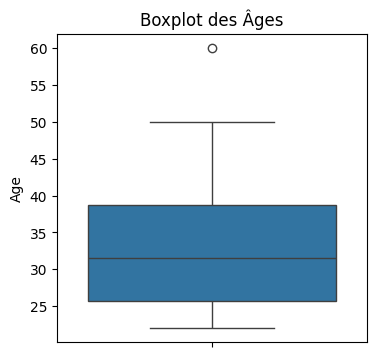

In [8]:
data = {'Age': [22, 25, 30, 35, 40, 22, 50, 60, 28, 33]}
df = pd.DataFrame(data)
print("Quantiles de l'âge :\n", df['Age'].quantile([0.25, 0.5, 0.75]))

plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title('Distribution des Âges')
plt.show()

plt.figure(figsize=(4,4))
sns.boxplot(y=df['Age'])
plt.title('Boxplot des Âges')
plt.show()

#### Exercice

Pour le dataset 'iris' de Seaborn, analysez la distribution de la colonne 'sepal_length' : calculez les quartiles et visualisez sa distribution avec un histogramme.

#### Correction


Quartiles de 'sepal_lentgh' :
 0.25    5.1
0.50    5.8
0.75    6.4
1.00    7.9
Name: sepal_length, dtype: float64


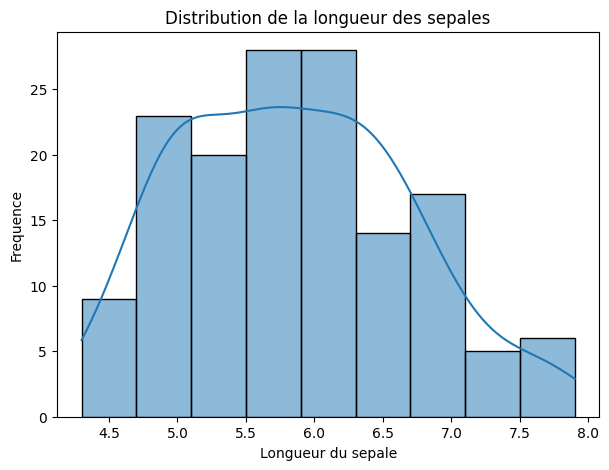

In [29]:
iris = sns.load_dataset('iris')
print("\nQuartiles de 'sepal_lentgh' :\n", iris['sepal_length'].quantile([0.25, 0.5, 0.75, 1.0]))

plt.figure(figsize=(7,5))
sns.histplot(iris['sepal_length'], kde=True)
plt.title("Distribution de la longueur des sepales")
plt.xlabel("Longueur du sepale")
plt.ylabel("Frequence")
plt.show()

Quartiles de 'sepal_length':
 0.25    5.1
0.50    5.8
0.75    6.4
Name: sepal_length, dtype: float64


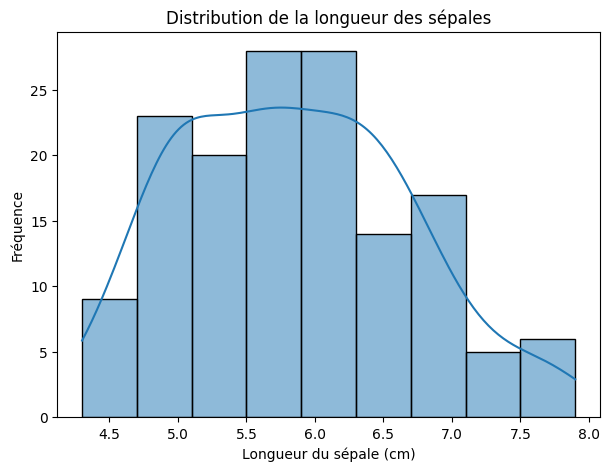

In [9]:
iris = sns.load_dataset('iris')
print("Quartiles de 'sepal_length':\n", iris['sepal_length'].quantile([0.25, 0.5, 0.75]))

plt.figure(figsize=(7,5))
sns.histplot(iris['sepal_length'], kde=True)
plt.title('Distribution de la longueur des sépales')
plt.xlabel('Longueur du sépale (cm)')
plt.ylabel('Fréquence')
plt.show()

---

### 5. Segmentation des données

#### Théorie

La segmentation des données consiste à diviser un dataset en sous-groupes basés sur des critères spécifiques, souvent des catégories. Cela se fait par filtrage ou en utilisant des fonctions comme `cut()` ou `qcut()` pour créer des classes à partir de variables numériques.

#### Exemple

In [ ]:
df = pd.DataFrame({'Revenu': [20000, 35000, 50000, 75000, 100000, 120000], 'Ville': ['A', 'B', 'A', 'C', 'B', 'A']})
print("Filtrage par ville A :\n", df[df['Ville'] == 'A'])   #Filtrage faire un mask sur la ville A 

# Création de catégories de revenu
df['Cat_Revenu'] = pd.cut(df['Revenu'], bins=[0, 40000, 80000, np.inf], labels=['Bas', 'Moyen', 'Haut'])  #bins = on appelle sa des intervalles entre sa et sa 
print("\nDataFrame avec catégories de revenu :\n", df)  #pd.cut fait une categorisation 

Filtrage par ville A :
    Revenu Ville
0   20000     A
2   50000     A
5  120000     A

DataFrame avec catégories de revenu :
    Revenu Ville Cat_Revenu
0   20000     A        Bas
1   35000     B        Bas
2   50000     A      Moyen
3   75000     C      Moyen
4  100000     B       Haut
5  120000     A       Haut


#### Exercice

Pour le DataFrame `df_etudiants` ci-dessous, segmentez les étudiants en groupes d'âge : 'Jeune' (moins de 20 ans), 'Adulte' (entre 20 et 30 ans inclus), 'Senior' (plus de 30 ans).
```python
df_etudiants = pd.DataFrame({
    'Nom': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [18, 22, 25, 31, 19],
    'Note': [15, 12, 18, 10, 16]
})
```

#### Correction

In [30]:
df_etudiants1 = pd.DataFrame({
    "Nom": ['Alice','Bob', 'Charlie', 'David', 'Eve'],
    "Age": [18, 22, 25, 31, 19],
    "Note": [15,12, 18, 10, 16]
})

df_etudiants1['Categorie_Age'] = pd.cut(df_etudiants['Age'],
bins =[0,19,20, np.inf],
labels = ['Jeune', 'Adulte', 'Senior'],
right=True)

print(df_etudiants1)

       Nom  Age  Note Categorie_Age
0    Alice   18    15         Jeune
1      Bob   22    12        Senior
2  Charlie   25    18        Senior
3    David   31    10        Senior
4      Eve   19    16         Jeune


In [11]:
df_etudiants = pd.DataFrame({
    'Nom': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [18, 22, 25, 31, 19],
    'Note': [15, 12, 18, 10, 16]
})
df_etudiants['Categorie_Age'] = pd.cut(df_etudiants['Age'],
                                      bins=[0, 19, 30, np.inf],
                                      labels=['Jeune', 'Adulte', 'Senior'],
                                      right=True) # Inclure la borne supérieure
print(df_etudiants)

       Nom  Age  Note Categorie_Age
0    Alice   18    15         Jeune
1      Bob   22    12        Adulte
2  Charlie   25    18        Adulte
3    David   31    10        Senior
4      Eve   19    16         Jeune


---

### 6. Fonctionnalité Groupby

#### Théorie

La méthode `groupby()` est l'une des plus puissantes de Pandas. Elle permet de regrouper des données par une ou plusieurs clés (colonnes) et d'appliquer ensuite une fonction d'agrégation (comme `sum()`, `mean()`, `count()`, `min()`, `max()`, `agg()`) à chaque groupe.

#### Exemple

In [20]:
df = pd.DataFrame({
    'Catégorie': ['A', 'B', 'A', 'B', 'A'],
    'Valeur': [10, 15, 20, 25, 30]
})
grouped_mean = df.groupby('Catégorie')['Valeur'].mean()
print("Moyenne par catégorie :\n", grouped_mean)

grouped_agg = df.groupby('Catégorie').agg({'Valeur': ['sum', 'count', 'mean', 'min', 'max']})
print("\nAgrégation multiple par catégorie :\n", grouped_agg)

Moyenne par catégorie :
 Catégorie
A    20.0
B    20.0
Name: Valeur, dtype: float64

Agrégation multiple par catégorie :
           Valeur                    
             sum count  mean min max
Catégorie                           
A             60     3  20.0  10  30
B             40     2  20.0  15  25


#### Exercice

En utilisant le dataset 'tips' de Seaborn : 
1. Calculez la 'tip' (pourboire) moyenne par jour de la semaine ('day').
2. Calculez la taille moyenne du groupe ('size') et le total de la facture ('total_bill') par genre ('sex') et par fumeur ('smoker').

In [33]:
tips = sns.load_dataset('tips')
print("\nMoyenne des pourboires par jour:\n", tips.groupby('day')['tip'].mean())

print("\nMoyenne taille groupe et total facture par genre et fumeur :\n", tips.groupby(['sex', 'smoker']).agg({'size': 'mean', 'total_bill': 'mean'}))


Moyenne des pourboires par jour:
 day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

Moyenne taille groupe et total facture par genre et fumeur :
                    size  total_bill
sex    smoker                      
Male   Yes     2.500000   22.284500
       No      2.711340   19.791237
Female Yes     2.242424   17.977879
       No      2.592593   18.105185


#### Correction

In [19]:
tips = sns.load_dataset('tips')
print("Moyenne des pourboires par jour :\n", tips.groupby('day')['tip'].mean())

print("\nMoyenne taille groupe et total facture par genre et fumeur :\n",
      tips.groupby(['sex', 'smoker']).agg({'size': 'mean', 'total_bill': 'mean'}))

Moyenne des pourboires par jour :
 day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

Moyenne taille groupe et total facture par genre et fumeur :
                    size  total_bill
sex    smoker                      
Male   Yes     2.500000   22.284500
       No      2.711340   19.791237
Female Yes     2.242424   17.977879
       No      2.592593   18.105185


---

### 7. Table Pivot

#### Théorie

Les tables pivot (`pivot_table`) permettent de transformer et de résumer des données, similaires aux tableaux croisés dynamiques dans Excel. Elles sont idéales pour agréger des données en fonction de multiples clés (lignes, colonnes, valeurs).

#### Exemple

In [3]:
df = pd.DataFrame({
    'Date': pd.to_datetime(['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-02']),
    'Produit': ['A', 'B', 'A', 'B'],
    'Ventes': [100, 150, 120, 180]
})
print(df)
pivot_table = df.pivot_table(values='Ventes', index='Date', columns='Produit', aggfunc='sum')
print(pivot_table)

        Date Produit  Ventes
0 2023-01-01       A     100
1 2023-01-01       B     150
2 2023-01-02       A     120
3 2023-01-02       B     180
Produit       A    B
Date                
2023-01-01  100  150
2023-01-02  120  180


#### Exercice

En utilisant le dataset 'titanic' de Seaborn, créez une table pivot qui affiche le taux de survie ('survived', 0 ou 1) moyen par classe ('class') et par genre ('sex').

#### Correction

In [5]:
titanic = sns.load_dataset('titanic')
pivot_table = titanic.pivot_table(values='survived', index='class', columns='sex', aggfunc='mean')
print(pivot_table)  

sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447


In [17]:
titanic = sns.load_dataset('titanic')
pivot_survie = titanic.pivot_table(values='survived', index='class', columns='sex', aggfunc='mean')
print(pivot_survie)

sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447


---

### 8. Liaison entre deux colonnes quantitatives

#### Théorie

Pour analyser la relation entre deux colonnes quantitatives, on peut utiliser des graphiques de dispersion (scatter plots) et calculer des mesures comme la **covariance** et la **corrélation**.

#### Exemple

Covariance entre X et Y : 2.0
Corrélation entre X et Y : 0.8528028654224418


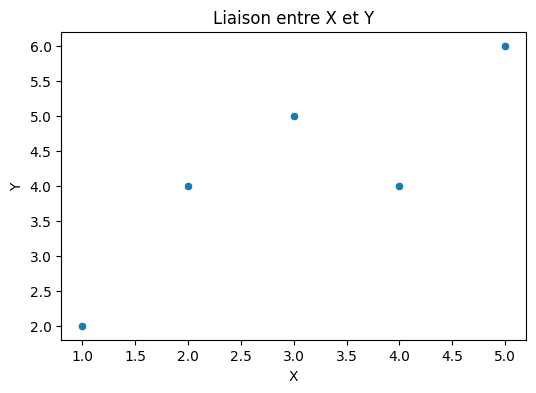

In [15]:
df = pd.DataFrame({
    'X': [1, 2, 3, 4, 5],
    'Y': [2, 4, 5, 4, 6]
})
print("Covariance entre X et Y :", df['X'].cov(df['Y']))
print("Corrélation entre X et Y :", df['X'].corr(df['Y']))

plt.figure(figsize=(6,4))
sns.scatterplot(x='X', y='Y', data=df)
plt.title('Liaison entre X et Y')
plt.show()

#### Exercice

Avec le dataset 'tips' de Seaborn, visualisez la relation entre 'total_bill' et 'tip' à l'aide d'un scatter plot. Interprétez la relation observée.

#### Correction

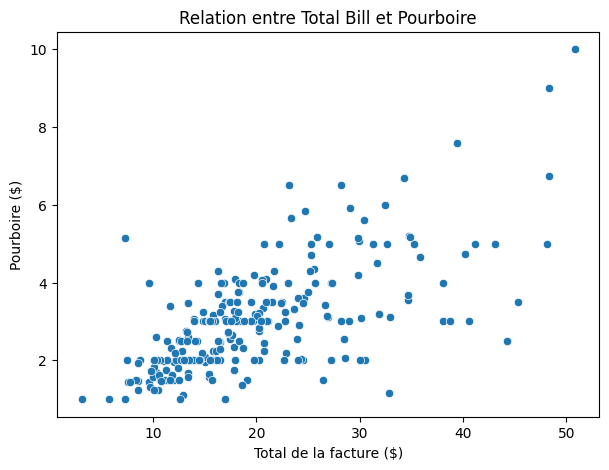

Interprétation : On observe généralement une corrélation positive, plus le montant de la facture est élevé, plus le pourboire tend à être élevé.


In [16]:
tips = sns.load_dataset('tips')
plt.figure(figsize=(7,5))
sns.scatterplot(x='total_bill', y='tip', data=tips)
plt.title('Relation entre Total Bill et Pourboire')
plt.xlabel('Total de la facture ($)')
plt.ylabel('Pourboire ($)')
plt.show()
print("Interprétation : On observe généralement une corrélation positive, plus le montant de la facture est élevé, plus le pourboire tend à être élevé.")

---

### 9. Calcul de la covariance et de la corrélation

#### Théorie

La **covariance** mesure la direction de la relation linéaire entre deux variables. Une covariance positive indique que les variables varient dans la même direction, négative qu'elles varient dans des directions opposées. La **corrélation** est une version normalisée de la covariance, allant de -1 à 1, indiquant à la fois la direction et la force de la relation linéaire. `df.corr()` calcule la matrice de corrélation pour toutes les paires de colonnes numériques.

#### Exemple

Matrice de covariance :
               Revenu  Dépenses  Satisfaction
Revenu         250.0    125.00        -22.50
Dépenses       125.0     62.50        -11.25
Satisfaction   -22.5    -11.25          2.50

Matrice de corrélation :
               Revenu  Dépenses  Satisfaction
Revenu           1.0       1.0          -0.9
Dépenses         1.0       1.0          -0.9
Satisfaction    -0.9      -0.9           1.0


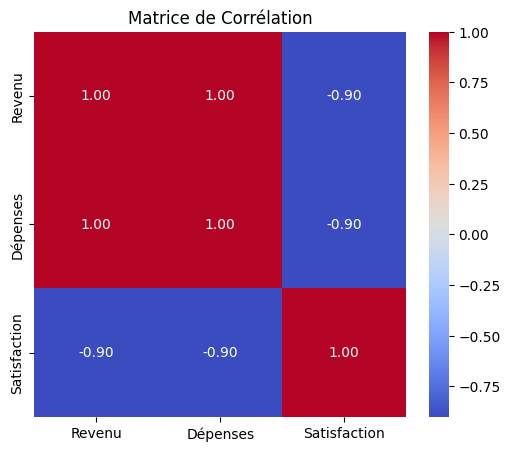

In [12]:
df = pd.DataFrame({
    'Revenu': [50, 60, 70, 80, 90],
    'Dépenses': [30, 35, 40, 45, 50],
    'Satisfaction': [9, 7, 8, 6, 5]
})
print("Matrice de covariance :\n", df.cov())
print("\nMatrice de corrélation :\n", df.corr())

# Visualisation de la matrice de corrélation
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation')
plt.show()

#### Exercice

Avec le dataset 'iris' de Seaborn, calculez la matrice de corrélation des longueurs et largeurs de sépales et de pétales. Interprétez les résultats.

#### Correction

Matrice de corrélation pour les mesures d'Iris :
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


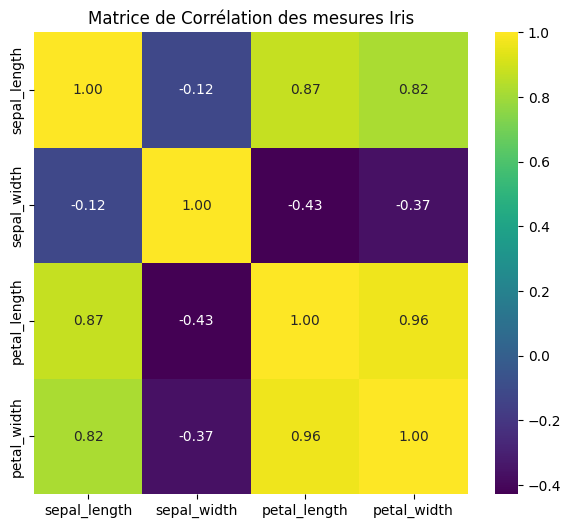


Interprétation : On observe une forte corrélation positive entre 'sepal_length' et 'petal_length' et 'petal_width', ce qui est attendu pour des caractéristiques de croissance.


In [14]:
iris = sns.load_dataset('iris')
colonnes_numeriques = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
matrice_cor = iris[colonnes_numeriques].corr()
print("Matrice de corrélation pour les mesures d'Iris :\n", matrice_cor)

plt.figure(figsize=(7,6))
sns.heatmap(matrice_cor, annot=True, cmap='viridis', fmt=".2f")
plt.title('Matrice de Corrélation des mesures Iris')
plt.show()
print("\nInterprétation : On observe une forte corrélation positive entre 'sepal_length' et 'petal_length' et 'petal_width', ce qui est attendu pour des caractéristiques de croissance.")

---

## Partie : Combiner plusieurs sources de données

---

### 10. Combinaison de Données avec concat

#### Théorie

La fonction `pd.concat()` permet de combiner des DataFrames le long d'un axe (lignes ou colonnes). Elle est utilisée pour empiler des DataFrames (ajout de lignes, `axis=0`) ou pour les coller côte à côte (ajout de colonnes, `axis=1`), lorsque les indices sont alignés ou doivent être ignorés.

#### Exemple

In [21]:
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
df3 = pd.DataFrame({'C': [9, 10], 'D': [11, 12]})

print("Concaténation par lignes (axis=0) :\n", pd.concat([df1, df2], axis=0))
print("\nConcaténation par colonnes (axis=1) :\n", pd.concat([df1, df3], axis=1))

Concaténation par lignes (axis=0) :
    A  B
0  1  3
1  2  4
0  5  7
1  6  8

Concaténation par colonnes (axis=1) :
    A  B   C   D
0  1  3   9  11
1  2  4  10  12


#### Exercice

Créez deux DataFrames : `df_produits_laitiers` (Produit, Prix) et `df_produits_frais` (Produit, Prix). Concaténez-les pour obtenir un DataFrame `df_tous_produits`.

#### Correction

In [22]:
df_produits_laitiers = pd.DataFrame({'Produit': ['Lait', 'Fromage'], 'Prix': [1.5, 5.0]})
df_produits_frais = pd.DataFrame({'Produit': ['Pomme', 'Banane'], 'Prix': [1.0, 0.8]})
df_tous_produits = pd.concat([df_produits_laitiers, df_produits_frais], axis=0, ignore_index=True)
print(df_tous_produits)

   Produit  Prix
0     Lait   1.5
1  Fromage   5.0
2    Pomme   1.0
3   Banane   0.8


---

### 11. Maîtriser les Jointures avec Pandas

#### Théorie

Les jointures (`merge()`) sont essentielles pour combiner des DataFrames basés sur des clés communes, comme les opérations de jointure en SQL.
- **`inner` (par défaut) :** Ne garde que les lignes où les clés sont présentes dans les deux DataFrames.
- **`left` :** Garde toutes les lignes du DataFrame de gauche et ajoute les correspondances du droit. Si pas de correspondance, NaNs.
- **`right` :** Garde toutes les lignes du DataFrame de droite et ajoute les correspondances du gauche. Si pas de correspondance, NaNs.
- **`outer` :** Garde toutes les lignes des deux DataFrames, remplissant avec des NaNs là où il n'y a pas de correspondance.

#### Exemple

In [23]:
df_commandes = pd.DataFrame({
    'order_id': [1, 2, 3, 4],
    'customer_id': [101, 102, 101, 103],
    'amount': [100, 150, 200, 50]
})
df_clients = pd.DataFrame({
    'customer_id': [101, 102, 104],
    'name': ['Alice', 'Bob', 'Charlie']
})

print("Inner Join :\n", pd.merge(df_commandes, df_clients, on='customer_id', how='inner'))
print("\nLeft Join :\n", pd.merge(df_commandes, df_clients, on='customer_id', how='left'))
print("\nRight Join :\n", pd.merge(df_commandes, df_clients, on='customer_id', how='right'))
print("\nOuter Join :\n", pd.merge(df_commandes, df_clients, on='customer_id', how='outer'))

Inner Join :
    order_id  customer_id  amount   name
0         1          101     100  Alice
1         2          102     150    Bob
2         3          101     200  Alice

Left Join :
    order_id  customer_id  amount   name
0         1          101     100  Alice
1         2          102     150    Bob
2         3          101     200  Alice
3         4          103      50    NaN

Right Join :
    order_id  customer_id  amount     name
0       1.0          101   100.0    Alice
1       3.0          101   200.0    Alice
2       2.0          102   150.0      Bob
3       NaN          104     NaN  Charlie

Outer Join :
    order_id  customer_id  amount     name
0       1.0          101   100.0    Alice
1       3.0          101   200.0    Alice
2       2.0          102   150.0      Bob
3       4.0          103    50.0      NaN
4       NaN          104     NaN  Charlie


#### Exercice

Vous avez deux DataFrames :
 - `df_employes`: 'id_employe', 'nom', 'departement'
 - `df_salaires`: 'id_employe', 'salaire', 'date_embauche'
Effectuez une jointure (`merge`) pour obtenir un DataFrame qui contient le nom de l'employé, son département et son salaire pour tous les employés ayant un enregistrement dans les deux DataFrames (jointure interne).
```python
df_employes = pd.DataFrame({
    'id_employe': [1, 2, 3, 4],
    'nom': ['Alice', 'Bob', 'Charlie', 'David'],
    'departement': ['RH', 'IT', 'Finance', 'IT']
})
df_salaires = pd.DataFrame({
    'id_employe': [1, 2, 5],
    'salaire': [60000, 75000, 50000],
    'date_embauche': pd.to_datetime(['2020-01-01', '2019-05-15', '2021-03-01'])
})
```

#### Correction

In [6]:
import pandas as pd

df_employes = pd.DataFrame({
    'id_employe': [1,2,3,4],
    'nom': ['Alice', 'Bob', 'Charlie', 'David'],
    'departement': ['RH', 'IT', 'Finance', 'IT']    
})
df_salaires = pd.DataFrame({
    'id_employe': [1,2,5],
    'salaire': [60000, 75000, 50000],
    'date_embauche': pd.to_datetime(['2020-01-01', '2019-05-15', '2021-03-01'])
})
df_resultat = pd.merge(df_employes, df_salaires, on='id_employe', how='left')
print(df_resultat)

   id_employe      nom departement  salaire date_embauche
0           1    Alice          RH  60000.0    2020-01-01
1           2      Bob          IT  75000.0    2019-05-15
2           3  Charlie     Finance      NaN           NaT
3           4    David          IT      NaN           NaT


In [7]:
df_employes = pd.DataFrame({
    'id_employe': [1, 2, 3, 4],
    'nom': ['Alice', 'Bob', 'Charlie', 'David'],
    'departement': ['RH', 'IT', 'Finance', 'IT']
})
df_salaires = pd.DataFrame({
    'id_employe': [1, 2, 5],
    'salaire': [60000, 75000, 50000],
    'date_embauche': pd.to_datetime(['2020-01-01', '2019-05-15', '2021-03-01'])
})
df_resultat = pd.merge(df_employes, df_salaires, on='id_employe', how='inner')
print(df_resultat)

   id_employe    nom departement  salaire date_embauche
0           1  Alice          RH    60000    2020-01-01
1           2    Bob          IT    75000    2019-05-15


---

## Exercice Complet : Système d'Analyse de Ventes (Orienté Objet)

Vous devez créer un système d'analyse pour une chaîne de magasins. Vous disposez de deux sources de données : les informations sur les produits et les données de ventes.

### Consignes :
1.  **Classe `Produit` :**
    * Attributs : `id_produit` (int), `nom_produit` (str), `categorie` (str), `prix_unitaire` (float).
    * Méthode : `__init__`.

2.  **Classe `Vente` :**
    * Attributs : `id_vente` (int), `id_produit` (int), `quantite_vendue` (int), `date_vente` (str).
    * Méthode : `__init__`.

3.  **Classe `AnalyseVentes` :**
    * Attributs : `produits_df` (DataFrame Pandas des produits), `ventes_df` (DataFrame Pandas des ventes).
    * Méthodes :
        * `__init__(liste_produits, liste_ventes)` : Prend des listes d'objets `Produit` et `Vente` et les convertit en DataFrames Pandas pour `produits_df` et `ventes_df`.
        * `preparer_donnees()` : Effectue une jointure interne (merge) entre `ventes_df` et `produits_df` sur `id_produit`.           Ajoute une colonne `revenu_total` (quantite_vendue * prix_unitaire).           Convertit la colonne `date_vente` en type datetime.
          Retourne le DataFrame combiné.
        * `analyser_ventes_par_categorie()` : Utilise `groupby()` sur le DataFrame préparé pour calculer le revenu total et la quantité totale vendue par `categorie`.
          Retourne un DataFrame récapitulatif.
        * `obtenir_produits_top_n(n=5)` : Retourne un DataFrame des `n` produits les plus vendus (en termes de `revenu_total`) en utilisant le DataFrame préparé.
        * `afficher_distribution_revenu()` : Affiche un histogramme de la distribution du `revenu_total`.

### Données de test :
```python
liste_produits_test = [
    Produit(1, 'Lait', 'Laitier', 1.5),
    Produit(2, 'Pain', 'Boulangerie', 2.0),
    Produit(3, 'Pomme', 'Fruits', 0.5),
    Produit(4, 'Yaourt', 'Laitier', 1.0),
    Produit(5, 'Céréales', 'Petit Déjeuner', 3.0)
]

liste_ventes_test = [
    Vente(101, 1, 5, '2024-01-05'),
    Vente(102, 2, 3, '2024-01-05'),
    Vente(103, 1, 2, '2024-01-06'),
    Vente(104, 3, 10, '2024-01-06'),
    Vente(105, 4, 4, '2024-01-07'),
    Vente(106, 2, 1, '2024-01-07'),
    Vente(107, 5, 2, '2024-01-08'),
    Vente(108, 3, 5, '2024-01-08'),
    Vente(109, 1, 1, '2024-01-09'),
    Vente(110, 4, 3, '2024-01-09')
]
```

### Questions :
1.  Créez une instance de `AnalyseVentes` avec les données de test.
2.  Obtenez et affichez le DataFrame combiné des ventes et produits.
3.  Affichez l'analyse des ventes par catégorie.
4.  Affichez le top 3 des produits les plus vendus.
5.  Affichez la distribution du revenu total. 6. Calculez la matrice de corrélation pour les colonnes numériques du DataFrame combiné.

### Correction de l'Exercice Complet

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class Produit:
    '''Classe representant un produit ou des produits'''    
    def __init__(self, id_produit, nom_produit, categorie, prix_unitaire):
        '''Methode d'initialisation de la classe Produit'''
        self.id_produit = id_produit
        self.nom_produit = nom_produit
        self.categorie = categorie
        self.prix_unitaire = prix_unitaire

class Vente:
    '''Classe representant une vente ou des ventes'''
    def __init__(self, id_vente, id_produit, quantite_vendue, date_vente):
        '''Methode d'initialisation de la classe Vente'''
        self.id_vente = id_vente
        self.id_produit = id_produit
        self.quantite_vendue = quantite_vendue
        self.date_vente = date_vente

class AnalyseVentes:
    '''Classe pour analyser les ventes et les produits'''   
    def __init__(self, liste_produits, liste_ventes):
        '''Methode d'initialisation de la classe AnalyseVentes'''
        self.produits_df = pd.DataFrame([vars(p) for p in liste_produits])
        self.ventes_df = pd.DataFrame([vars(v) for v in liste_ventes])
        self.df_combine = None 

    def preparer_donnees(self):
        '''Methode pour preparer les donnees en combinant les produits et les ventes'''   
        self.df_combine = pd.merge(
            self.ventes_df, self.produits_df, left_on='id_produit', right_on='id_produit', how='inner'
        )
        self.df_combine['revenu_total'] = self.df_combine['quantite_vendue'] * self.df_combine['prix_unitaire']
        self.df_combine['date_vente'] = pd.to_datetime(self.df_combine['date_vente'])
        return self.df_combine

    def analyser_ventes_par_categorie(self):
        '''Methode pour analyser les ventes par categorie de produit'''
        if self.df_combine is None:
            print("\nVeuillez dabord preparer les donnees en appelant la methode preparer_donnees()\n")
            return None  
        return self.df_combine.groupby('categorie').agg({'revenu_total': 'sum', 'quantite_vendue': 'sum'}).reset_index()

    
    def obtenir_produits_top_n(self):
        '''Methode pour obtenir les produits les plus vendus en termes de revenu total'''  
        if self.df_combine is None:
            print("\nVeuillez dabord preparer les donnees en appelant la methode preparer_donnees()\n")
            return None
        top_n_produits = self.df_combine.groupby('nom_produit').agg({'revenu_total': 'sum'}).reset_index() 
        return top_n_produits.reset_index() 

    def afficher_distribution_revenu(self):
        if self.df_combine is None:
            print("\nVeuillez dabord preparer les donnees en appelant la methode preparer_donnees()\n")
            return None
        plt.figure(figsize=(8,6))
        sns.histplot(self.df_combine['revenu_total'], kde=True, bins=5)
        plt.title('Distribution du Revenu Total par Vente')
        plt.xlabel('Revenu Total ($)')
        plt.ylabel('Fréquence')
        plt.show()

    def calculer_correlation_combine(self):
        if self.df_combine is None:
            print("\nVeuillez dabord preparer les donnees en appelant la methode preparer_donnees()\n")
            return None
        numeric_cols = self.df_combine.select_dtypes(include=np.number).columns
        return self.df_combine[numeric_cols].corr()
        
        


--- Exemple d'utilisation de la classe AnalyseVentes ---

Données combinées :
    id_vente  id_produit  quantite_vendue date_vente nom_produit  \
0       101           1                5 2024-01-05        Lait   
1       102           2                3 2024-01-05        Pain   
2       103           1                2 2024-01-06        Lait   
3       104           3               10 2024-01-06       Pomme   
4       105           4                4 2024-01-07      Yaourt   
5       106           2                1 2024-01-07        Pain   
6       107           5                2 2024-01-08    Céréales   
7       108           3                5 2024-01-08       Pomme   
8       109           1                1 2024-01-09        Lait   
9       110           4                3 2024-01-09      Yaourt   

        categorie  prix_unitaire  revenu_total  
0         Laitier            1.5           7.5  
1     Boulangerie            2.0           6.0  
2         Laitier            1.5   

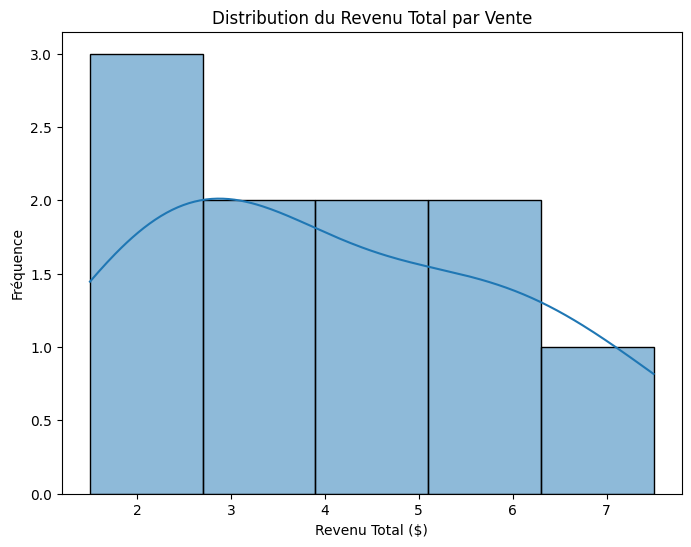


Distribution du revenu total par vente affichée.
 None

Matrice de corrélation des données combinées :
                  id_vente  id_produit  quantite_vendue  prix_unitaire  \
id_vente         1.000000    0.436328        -0.301823      -0.108371   
id_produit       0.436328    1.000000         0.156871       0.081590   
quantite_vendue -0.301823    0.156871         1.000000      -0.637822   
prix_unitaire   -0.108371    0.081590        -0.637822       1.000000   
revenu_total    -0.676931    0.124812         0.389863       0.294603   

                 revenu_total  
id_vente            -0.676931  
id_produit           0.124812  
quantite_vendue      0.389863  
prix_unitaire        0.294603  
revenu_total         1.000000  


In [13]:
print("\n--- Exemple d'utilisation de la classe AnalyseVentes ---\n")

# Création de quelques produits# --- Données de test ---

liste_produits_test = [
    Produit(1, 'Lait', 'Laitier', 1.5),
    Produit(2, 'Pain', 'Boulangerie', 2.0),
    Produit(3, 'Pomme', 'Fruits', 0.5),
    Produit(4, 'Yaourt', 'Laitier', 1.0),
    Produit(5, 'Céréales', 'Petit Déjeuner', 3.0)
]

liste_ventes_test = [
    Vente(101, 1, 5, '2024-01-05'),
    Vente(102, 2, 3, '2024-01-05'),
    Vente(103, 1, 2, '2024-01-06'),
    Vente(104, 3, 10, '2024-01-06'),
    Vente(105, 4, 4, '2024-01-07'),
    Vente(106, 2, 1, '2024-01-07'),
    Vente(107, 5, 2, '2024-01-08'),
    Vente(108, 3, 5, '2024-01-08'),
    Vente(109, 1, 1, '2024-01-09'),
    Vente(110, 4, 3, '2024-01-09')
]

analyseur = AnalyseVentes(liste_produits_test, liste_ventes_test)
df_combine = analyseur.preparer_donnees()
print("Données combinées :\n", df_combine)

ventes_par_categorie = analyseur.analyser_ventes_par_categorie()
print("\nVentes par catégorie :\n", ventes_par_categorie)

top_produits = analyseur.obtenir_produits_top_n()
print("\nProduits les plus vendus (en termes de revenu total) :\n", top_produits)

distribution = analyseur.afficher_distribution_revenu()
print("\nDistribution du revenu total par vente affichée.\n", distribution)

correlation = analyseur.calculer_correlation_combine()
print("\nMatrice de corrélation des données combinées :\n", correlation)




--- Instance AnalyseVentes créée ---

--- DataFrame Combiné des Ventes et Produits ---
   id_vente  id_produit  quantite_vendue date_vente nom_produit  \
0       101           1                5 2024-01-05        Lait   
1       102           2                3 2024-01-05        Pain   
2       103           1                2 2024-01-06        Lait   
3       104           3               10 2024-01-06       Pomme   
4       105           4                4 2024-01-07      Yaourt   
5       106           2                1 2024-01-07        Pain   
6       107           5                2 2024-01-08    Céréales   
7       108           3                5 2024-01-08       Pomme   
8       109           1                1 2024-01-09        Lait   
9       110           4                3 2024-01-09      Yaourt   

        categorie  prix_unitaire  revenu_total  
0         Laitier            1.5           7.5  
1     Boulangerie            2.0           6.0  
2         Laitier          

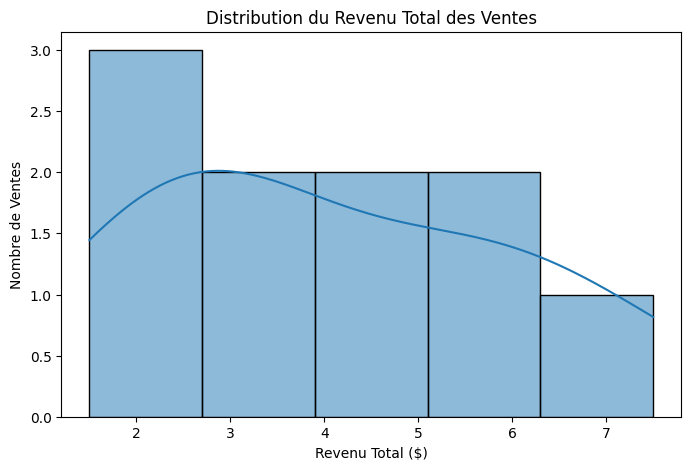


--- Matrice de Corrélation des Données Combinées ---
                 id_vente  id_produit  quantite_vendue  prix_unitaire  \
id_vente         1.000000    0.436328        -0.301823      -0.108371   
id_produit       0.436328    1.000000         0.156871       0.081590   
quantite_vendue -0.301823    0.156871         1.000000      -0.637822   
prix_unitaire   -0.108371    0.081590        -0.637822       1.000000   
revenu_total    -0.676931    0.124812         0.389863       0.294603   

                 revenu_total  
id_vente            -0.676931  
id_produit           0.124812  
quantite_vendue      0.389863  
prix_unitaire        0.294603  
revenu_total         1.000000  


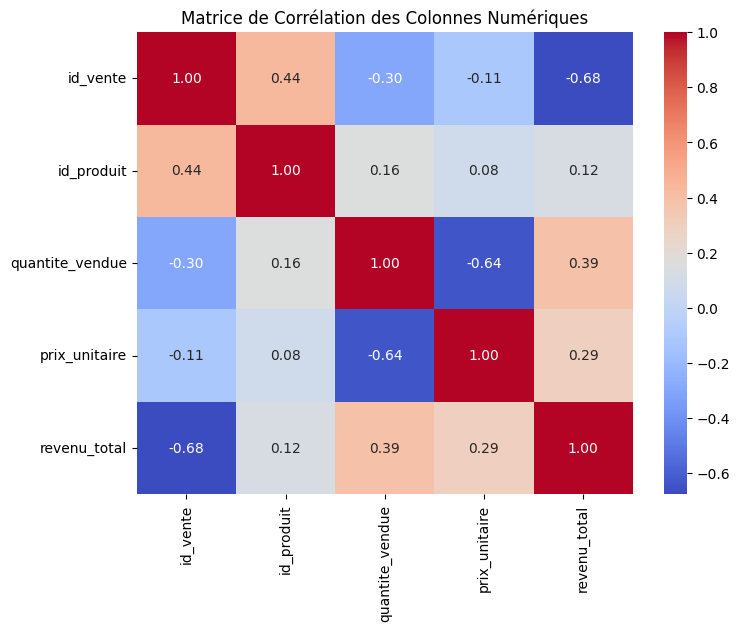

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class Produit:
    def __init__(self, id_produit, nom_produit, categorie, prix_unitaire):
        self.id_produit = id_produit
        self.nom_produit = nom_produit
        self.categorie = categorie
        self.prix_unitaire = prix_unitaire

class Vente:
    def __init__(self, id_vente, id_produit, quantite_vendue, date_vente):
        self.id_vente = id_vente
        self.id_produit = id_produit
        self.quantite_vendue = quantite_vendue
        self.date_vente = date_vente

class AnalyseVentes:
    def __init__(self, liste_produits, liste_ventes):
        self.produits_df = pd.DataFrame([vars(p) for p in liste_produits])
        self.ventes_df = pd.DataFrame([vars(v) for v in liste_ventes])
        self.df_combine = None # Sera rempli après preparation_donnees

    def preparer_donnees(self):
        # Jointure des ventes et produits
        self.df_combine = pd.merge(
            self.ventes_df,
            self.produits_df,
            on='id_produit',
            how='inner'
        )
        # Calcul du revenu total
        self.df_combine['revenu_total'] = self.df_combine['quantite_vendue'] * self.df_combine['prix_unitaire']
        # Conversion de la date
        self.df_combine['date_vente'] = pd.to_datetime(self.df_combine['date_vente'])
        return self.df_combine

    def analyser_ventes_par_categorie(self):
        if self.df_combine is None:
            print("Veuillez d'abord exécuter preparer_donnees().")
            return None
        return self.df_combine.groupby('categorie').agg(
            total_revenu=('revenu_total', 'sum'),
            total_quantite=('quantite_vendue', 'sum')
        ).reset_index()

    def obtenir_produits_top_n(self, n=5):
        if self.df_combine is None:
            print("Veuillez d'abord exécuter preparer_donnees().")
            return None
        # Regrouper par produit et sommer le revenu, puis trier
        top_n_produits = self.df_combine.groupby('nom_produit')['revenu_total'].sum().nlargest(n)
        return top_n_produits.reset_index()

    def afficher_distribution_revenu(self):
        if self.df_combine is None:
            print("Veuillez d'abord exécuter preparer_donnees().")
            return
        plt.figure(figsize=(8, 5))
        sns.histplot(self.df_combine['revenu_total'], kde=True, bins=5)
        plt.title('Distribution du Revenu Total des Ventes')
        plt.xlabel('Revenu Total ($)')
        plt.ylabel('Nombre de Ventes')
        plt.show()
    
    def calculer_correlation_combine(self):
        if self.df_combine is None:
            print("Veuillez d'abord exécuter preparer_donnees().")
            return None
        # Sélectionner uniquement les colonnes numériques pour la corrélation
        numeric_cols = self.df_combine.select_dtypes(include=np.number).columns
        return self.df_combine[numeric_cols].corr()


# --- Données de test ---
liste_produits_test = [
    Produit(1, 'Lait', 'Laitier', 1.5),
    Produit(2, 'Pain', 'Boulangerie', 2.0),
    Produit(3, 'Pomme', 'Fruits', 0.5),
    Produit(4, 'Yaourt', 'Laitier', 1.0),
    Produit(5, 'Céréales', 'Petit Déjeuner', 3.0)
]

liste_ventes_test = [
    Vente(101, 1, 5, '2024-01-05'),
    Vente(102, 2, 3, '2024-01-05'),
    Vente(103, 1, 2, '2024-01-06'),
    Vente(104, 3, 10, '2024-01-06'),
    Vente(105, 4, 4, '2024-01-07'),
    Vente(106, 2, 1, '2024-01-07'),
    Vente(107, 5, 2, '2024-01-08'),
    Vente(108, 3, 5, '2024-01-08'),
    Vente(109, 1, 1, '2024-01-09'),
    Vente(110, 4, 3, '2024-01-09')
]

# 1. Créez une instance de AnalyseVentes
analyseur = AnalyseVentes(liste_produits_test, liste_ventes_test)
print("\n--- Instance AnalyseVentes créée ---")

# 2. Obtenez et affichez le DataFrame combiné
df_ventes_produits = analyseur.preparer_donnees()
print("\n--- DataFrame Combiné des Ventes et Produits ---")
print(df_ventes_produits)

# 3. Affichez l'analyse des ventes par catégorie
df_analyse_categorie = analyseur.analyser_ventes_par_categorie()
print("\n--- Analyse des Ventes par Catégorie ---")
print(df_analyse_categorie)

# 4. Affichez le top 3 des produits les plus vendus
df_top_produits = analyseur.obtenir_produits_top_n(n=3)
print("\n--- Top 3 des Produits les Plus Vendus (par revenu) ---")
print(df_top_produits)

# 5. Affichez la distribution du revenu total
print("\n--- Distribution du Revenu Total ---")
analyseur.afficher_distribution_revenu()

# 6. Calculez la matrice de corrélation pour les colonnes numériques
print("\n--- Matrice de Corrélation des Données Combinées ---")
matrice_corr = analyseur.calculer_correlation_combine()
print(matrice_corr)
plt.figure(figsize=(8,6))
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Colonnes Numériques')
plt.show()